In [11]:
# Read csv into pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Had to remove manually the first two lines since they where 2 elements long
df_untouched = pd.read_csv('imf-dm-export-20250916.csv')

In [12]:
# Make a copy of the untouched DataFrame
df = df_untouched.copy()

# Rename first column
df.rename(columns={df.columns[0]: 'Country Name'}, inplace=True)

# Selection of countries
countries = ['Italy', 'Switzerland', 'France', 'Poland']
df = df[df['Country Name'].isin(countries)]
# Selection of years
years = [str(year) for year in range(2002, 2031)]
df = df[['Country Name'] + years]

print(df.head())

    Country Name  2002  2003 2004 2005 2006 2007 2008  2009 2010  ... 2021  \
61        France   1.1     1  2.5    2  2.9  2.5  0.3  -2.7  1.8  ...  6.8   
84         Italy   0.3   0.1  1.5  0.8  1.8  1.5   -1  -5.3  1.5  ...  8.9   
139       Poland   1.4   3.5  5.1  3.3  6.2  6.8  4.4   2.6  3.2  ...  6.9   
168  Switzerland  -0.1  -0.1  2.6  2.9  4.2  3.9  2.7  -2.3  3.2  ...  5.6   

    2022 2023 2024 2025 2026 2027 2028 2029 2030  
61   2.6  1.1  1.1  0.6    1  1.2  1.3  1.2  1.2  
84   4.8  0.7  0.7  0.4  0.8  0.6  0.7  0.7  0.7  
139  5.3  0.1  2.9  3.2  3.1    3  2.9  2.8  2.7  
168  3.1  0.7  1.3  0.9  1.6  1.2  1.8  1.2  1.8  

[4 rows x 30 columns]


In [13]:
# Sum from 2025 to 2030
df['Sum 2025-2030'] = df[[str(year) for year in range(2024, 2031)]].apply(pd.to_numeric, errors='coerce').sum(axis=1)
print(df[['Country Name', 'Sum 2025-2030']])

    Country Name  Sum 2025-2030
61        France            7.6
84         Italy            4.6
139       Poland           20.6
168  Switzerland            9.8


In [14]:
# Save to a new CSV file
df.to_csv('Real_GDP_annual_growth.csv', index=False)

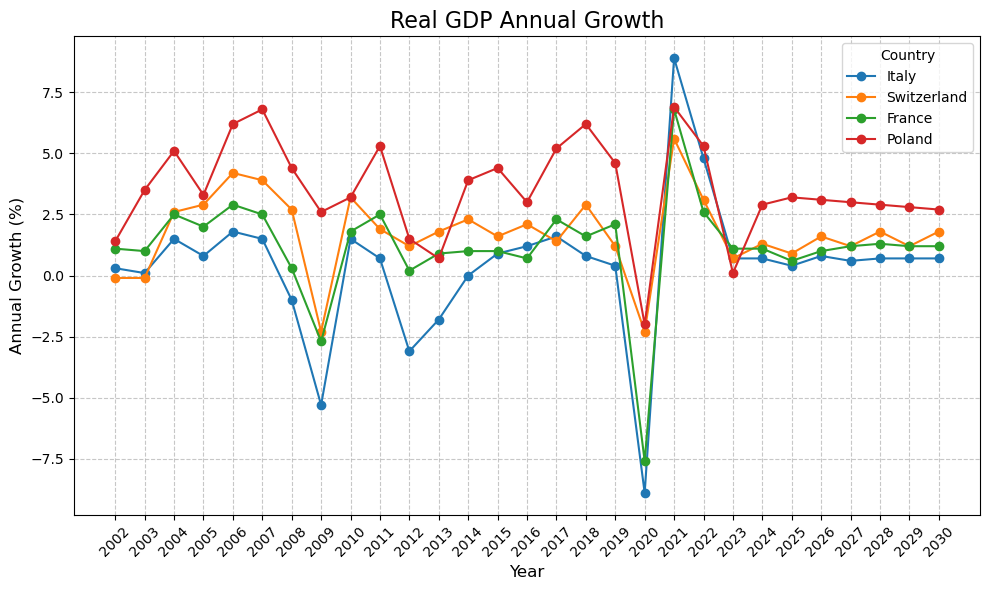

In [15]:
# Plot the data with improved formatting
figure, ax = plt.subplots(figsize=(10, 6))

for country in countries:
    country_data = df[df['Country Name'] == country]
    # Convert values to float for plotting
    values = country_data[years].values.flatten().astype(float)
    ax.plot(years, values, marker='o', label=country)

ax.set_title('Real GDP Annual Growth', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Growth (%)', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(title='Country')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()